# 생물정보학 및 실습 1 - Own Analysis 2: Lin28a 결합 강도에 따른 번역 효율(TE) 변화의 정량적 상관관계 분석

이 노트북은 `OwnAnalysis1.ipynb`에서 진행한 분석을 심화하여, Lin28a 단백질의 결합 강도(CLIP Enrichment)와 타겟 mRNA들의 번역 효율(Translation Efficiency, TE) 변화량 간의 정량적 상관관계를 분석합니다.

앞선 분석에서는 타겟 유전자(상위 20%)와 비타겟 유전자를 단순 비교하여 Lin28a knockdown 시 타겟 유전자의 번역 효율이 증가함을 확인했습니다. 
이번 분석에서는:
1. 타겟 유전자들을 결합 강도에 따라 4개의 그룹(Quartiles)으로 세분화하여, 결합 강도와 번역 억제 해제(Derepression) 정도가 비례하는지(Graded effect) 확인합니다.
2. 산점도(Scatter plot)와 통계적 상관계수(Spearman correlation)를 계산하여 두 변수 간의 직접적인 상관관계를 검증합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 데이터 로드 및 전처리
filepath = 'binfo1-work/read-counts.txt'
try:
    counts = pd.read_csv(filepath, sep='\t', comment='#')
except FileNotFoundError:
    counts = pd.read_csv('read-counts.txt', sep='\t', comment='#')

# 노이즈 필터링: RNA 및 RPF count가 10 이상인 유전자 선정
min_count = 10
filtered_counts = counts[
    (counts['RNA-siLuc.bam'] >= min_count) &
    (counts['RNA-siLin28a.bam'] >= min_count) &
    (counts['RPF-siLuc.bam'] >= min_count) &
    (counts['RPF-siLin28a.bam'] >= min_count) &
    (counts['RNA-control.bam'] >= min_count)
].copy()

print(f"필터링 후 유전자 수: {len(filtered_counts)}")

필터링 후 유전자 수: 11306


## TE 및 CLIP Enrichment 계산
이전 분석과 동일하게 TE와 TE log2 Fold Change, 그리고 CLIP Enrichment를 계산합니다.

In [3]:
# TE 및 Log2 Fold Change 계산
filtered_counts['TE_siLuc'] = filtered_counts['RPF-siLuc.bam'] / filtered_counts['RNA-siLuc.bam']
filtered_counts['TE_siLin28a'] = filtered_counts['RPF-siLin28a.bam'] / filtered_counts['RNA-siLin28a.bam']
filtered_counts['log2_fc_TE'] = np.log2(filtered_counts['TE_siLin28a']) - np.log2(filtered_counts['TE_siLuc'])

# CLIP Enrichment 계산
filtered_counts['CLIP_enrichment'] = filtered_counts['CLIP-35L33G.bam'] / filtered_counts['RNA-control.bam']
filtered_counts.loc[filtered_counts['CLIP-35L33G.bam'] == 0, 'CLIP_enrichment'] = 0

# TE의 log2FC가 극단적인 아웃라이어를 일부 제거하여 시각화 및 분석의 안정성 확보
# 1% ~ 99% 범위 내 데이터만 사용
lower_bound = filtered_counts['log2_fc_TE'].quantile(0.01)
upper_bound = filtered_counts['log2_fc_TE'].quantile(0.99)
data_clean = filtered_counts[(filtered_counts['log2_fc_TE'] >= lower_bound) & (filtered_counts['log2_fc_TE'] <= upper_bound)].copy()

print(f"아웃라이어 제거 후 유전자 수: {len(data_clean)}")

아웃라이어 제거 후 유전자 수: 11078


## 타겟 유전자의 세분화 (Quartile binning)
CLIP Enrichment가 0보다 큰 타겟 유전자들을 결합 강도에 따라 4개의 그룹(Q1~Q4)으로 나누고, Non-target(결합 없음)과 비교합니다.

In [4]:
# Non-target 분류 (CLIP enrichment == 0)
non_targets = data_clean[data_clean['CLIP_enrichment'] == 0].copy()
non_targets['Group'] = 'Non-target'

# Target 분류 및 Quartile 분할 (CLIP enrichment > 0)
targets = data_clean[data_clean['CLIP_enrichment'] > 0].copy()
targets['Quartile'] = pd.qcut(targets['CLIP_enrichment'], 4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
targets['Group'] = targets['Quartile'].astype(str)

# 데이터 결합
final_data = pd.concat([non_targets, targets])

# 그룹별 데이터 수 확인
print("그룹별 유전자 수:")
print(final_data['Group'].value_counts().sort_index())

그룹별 유전자 수:
Group
Non-target      25
Q1 (Low)      2764
Q2            2763
Q3            2763
Q4 (High)     2763
Name: count, dtype: int64


## 시각화 1: 결합 강도에 따른 TE 변화량 비교 (Violin Plot)
Lin28a 결합 강도가 높을수록(Q4에 가까울수록) Knockdown 시 TE 증가폭(Derepression)이 더 큰지 확인합니다.

/tmp/ipykernel_3570/3479892834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='log2_fc_TE', data=final_data, order=order, palette='Set2')


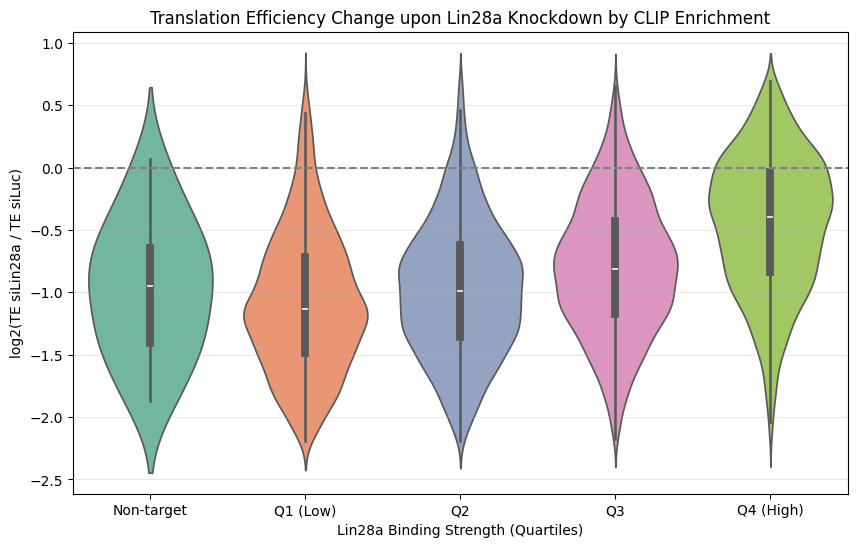

In [5]:
plt.figure(figsize=(10, 6))
order = ['Non-target', 'Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
sns.violinplot(x='Group', y='log2_fc_TE', data=final_data, order=order, palette='Set2')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Translation Efficiency Change upon Lin28a Knockdown by CLIP Enrichment')
plt.xlabel('Lin28a Binding Strength (Quartiles)')
plt.ylabel('log2(TE siLin28a / TE siLuc)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 시각화 2: 결합 강도에 따른 누적분포함수 (CDF) 비교
이전 분석의 이분법적 분류를 넘어서, 그룹별 분포의 차이를 명확하게 확인합니다.

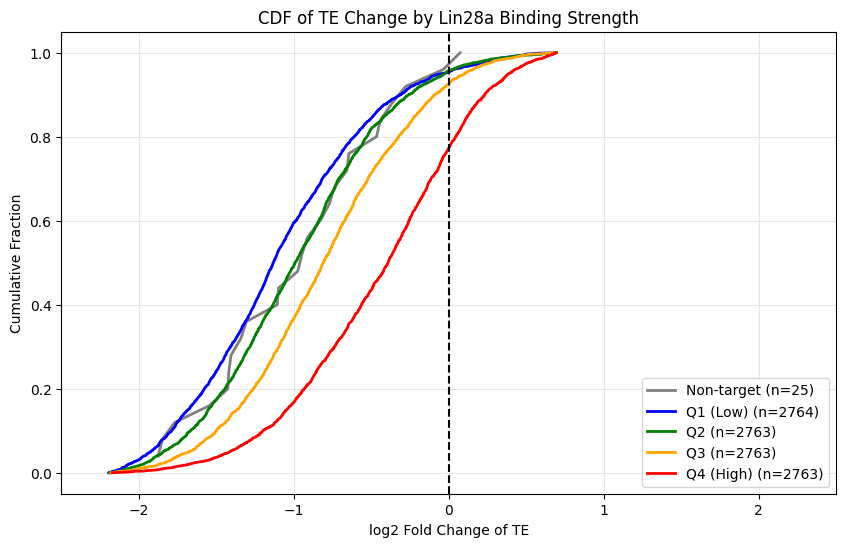

Non-target과 Q4 (High) 간의 KS test 결과: statistic=0.4057, p-value=3.39e-04


In [6]:
plt.figure(figsize=(10, 6))
colors = {'Non-target': 'gray', 'Q1 (Low)': 'blue', 'Q2': 'green', 'Q3': 'orange', 'Q4 (High)': 'red'}

for group in order:
    group_data = final_data[final_data['Group'] == group]['log2_fc_TE']
    x = np.sort(group_data)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=f'{group} (n={len(x)})', color=colors[group], linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.xlim(-2.5, 2.5)
plt.title('CDF of TE Change by Lin28a Binding Strength')
plt.xlabel('log2 Fold Change of TE')
plt.ylabel('Cumulative Fraction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 통계 검정 (Non-target vs Q4 High)
ks_stat, p_val = stats.ks_2samp(
    final_data[final_data['Group'] == 'Non-target']['log2_fc_TE'],
    final_data[final_data['Group'] == 'Q4 (High)']['log2_fc_TE']
)
print(f"Non-target과 Q4 (High) 간의 KS test 결과: statistic={ks_stat:.4f}, p-value={p_val:.2e}")

## 상관관계 분석 (Correlation Analysis)
CLIP Enrichment (log scale)와 TE 변화량 간의 직접적인 상관관계를 살펴봅니다.

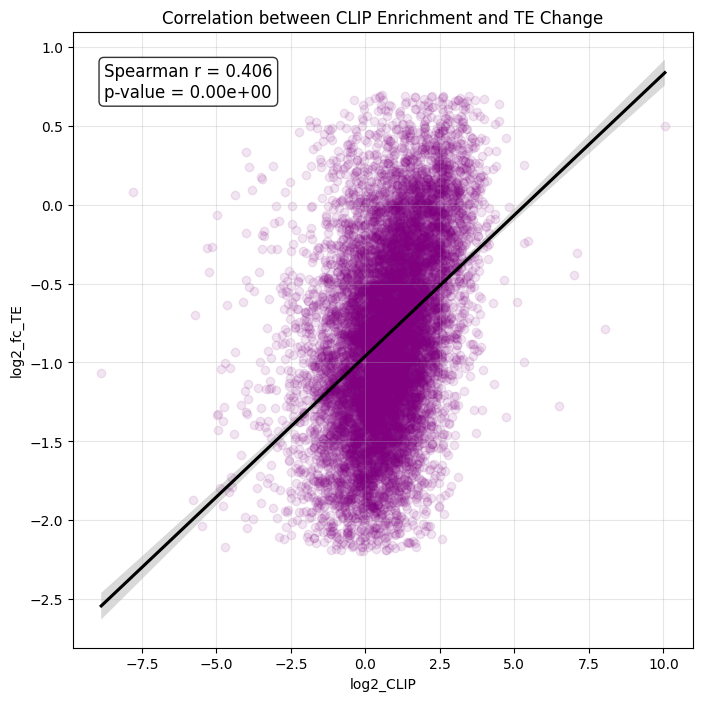

In [7]:
# CLIP Enrichment가 0보다 큰 데이터만 사용
plot_data = targets.copy()
# CLIP Enrichment는 넓은 범위를 가지므로 log2 변환하여 시각화
plot_data['log2_CLIP'] = np.log2(plot_data['CLIP_enrichment'])

# Spearman 상관계수 계산 (비모수적 순위 상관관계)
spearman_corr, p_value = stats.spearmanr(plot_data['CLIP_enrichment'], plot_data['log2_fc_TE'])

plt.figure(figsize=(8, 8))
plt.scatter(plot_data['log2_CLIP'], plot_data['log2_fc_TE'], alpha=0.1, color='purple')
plt.title('Correlation between CLIP Enrichment and TE Change')
plt.xlabel('log2(CLIP Enrichment)')
plt.ylabel('log2 Fold Change of TE (siLin28a/siLuc)')
plt.grid(True, alpha=0.3)

# 회귀선 추가
sns.regplot(x='log2_CLIP', y='log2_fc_TE', data=plot_data, scatter=False, color='black')

plt.text(0.05, 0.95, f'Spearman r = {spearman_corr:.3f}\np-value = {p_value:.2e}', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()